# 01 — Binary Theory Benchmarks

Theorem-aligned Bernoulli experiments: lower-bound comparison, first-order convergence, Price of Certification, false-unlock control, final decision error, baselines, and finite-confidence overshoot.

**Execution modes:** `SMOKE_TEST=1` performs a small offline code-path check; default settings run a moderate benchmark; `FULL_RUN=1` enables publication-scale Monte Carlo. Smoke outputs are verification-only and must not be reported as experimental results.

In [1]:
from pathlib import Path
import os, sys, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == 'notebooks' else HERE
if not (ROOT/'src'/'gated_benchmarks.py').exists():
    for cand in [HERE, *HERE.parents]:
        if (cand/'src'/'gated_benchmarks.py').exists():
            ROOT = cand; break
sys.path.insert(0, str(ROOT/'src'))
( ROOT/'results').mkdir(exist_ok=True)
( ROOT/'figures').mkdir(exist_ok=True)
FULL_RUN = os.getenv('FULL_RUN','0') == '1'
SMOKE_TEST = os.getenv('SMOKE_TEST','0') == '1'
print('ROOT =', ROOT)
print('FULL_RUN =', FULL_RUN, 'SMOKE_TEST =', SMOKE_TEST)


ROOT = /mnt/data/gated_certification_benchmarks
FULL_RUN = False SMOKE_TEST = True


In [2]:
from gated_benchmarks import *

weak = BernoulliAction(0.7, 0.5, 'weak')
strong = BernoulliAction(0.8, 0.2, 'strong')
actions = [weak, strong]
print('d_w =', weak.d0, 'd_s =', strong.d0)
print('increment bounds =', weak.c, strong.c)


d_w = 0.08228287850505184 d_s = 0.8317766166719343
increment bounds = 0.5108256237659905 1.3862943611198908


## 1. Main benchmark: lower bound vs proposed vs oracle/baselines

In [3]:
deltas = [1e-1, 5e-2, 1e-2, 1e-3] if not FULL_RUN else [1e-1,5e-2,1e-2,1e-3,1e-4,1e-5]
rho = 0.4
n_trials = 300 if SMOKE_TEST else (2500 if not FULL_RUN else 10000)
policies = ['running_max','oracle','weak_only','fixed','current_evidence']
rows=[]
for delta in deltas:
    alpha = delta**rho
    beta = delta
    Kc = binary_kl(1-beta, alpha)
    Kf = binary_kl(1-delta, delta)
    LB = Kc/weak.d0 + max(0,Kf-Kc)/strong.d0
    for pol in policies:
        for h in [0,1]:
            df = simulate_binary_ladder(actions,[alpha],delta,h,n_trials=n_trials,seed=1000+int(1e6*delta)+10*h+policies.index(pol),policy=pol)
            s = summarize_binary_runs(df)
            rows.append({'delta':delta,'alpha':alpha,'rho':rho,'policy':pol,'true_h':h,'LB_H0':LB,**s})
main = pd.DataFrame(rows)
main.to_csv(ROOT/'results'/'binary_main_benchmark.csv',index=False)
main.head()


,delta,alpha,rho,policy,true_h,LB_H0,n_trials,mean_tau,mean_tau_ci_lo,mean_tau_ci_hi,median_tau,q95_tau,error_rate,error_ci_lo,error_ci_hi,false_unlock_rate,false_unlock_ci_lo,false_unlock_ci_hi,failed_unlock_rate,mean_relocks,mean_N1,mean_N2
0,0.1,0.398107,0.4,running_max,0,8.186848,300,12.100000,10.963675,13.236325,9.0,30.1,0.060000,0.038286,0.092839,0.000000,8.673617e-19,0.012643,0.04,0.0,10.473333,1.626667
1,0.1,0.398107,0.4,running_max,1,8.186848,300,16.826667,15.421263,18.232071,13.0,41.1,0.090000,0.062590,0.127777,0.336667,2.855554e-01,0.391908,0.00,0.0,15.710000,1.116667
2,0.1,0.398107,0.4,oracle,0,8.186848,300,2.813333,2.656064,2.970603,2.0,6.0,0.080000,0.054347,0.116273,NaN,NaN,NaN,NaN,0.0,0.000000,2.813333
3,0.1,0.398107,0.4,oracle,1,8.186848,300,2.946667,2.745266,3.148067,2.0,6.0,0.066667,0.043568,0.100723,NaN,NaN,NaN,NaN,0.0,0.000000,2.946667
4,0.1,0.398107,0.4,weak_only,0,8.186848,300,26.113333,23.799818,28.426849,20.0,68.1,0.076667,0.051628,0.112410,NaN,NaN,NaN,NaN,0.0,26.113333,0.000000


In [4]:
tab = main[(main.true_h==0)][['delta','policy','mean_tau','mean_tau_ci_lo','mean_tau_ci_hi','error_rate','false_unlock_rate','LB_H0']].copy()
tab['gap_to_LB']=tab['mean_tau']/tab['LB_H0']
display(tab)


,delta,policy,mean_tau,mean_tau_ci_lo,mean_tau_ci_hi,error_rate,false_unlock_rate,LB_H0,gap_to_LB
0,0.100,running_max,12.100000,10.963675,13.236325,0.060000,0.0,8.186848,1.477980
2,0.100,oracle,2.813333,2.656064,2.970603,0.080000,NaN,8.186848,0.343641
4,0.100,weak_only,26.113333,23.799818,28.426849,0.076667,NaN,8.186848,3.189669
6,0.100,fixed,13.216667,12.866637,13.566696,0.056667,0.0,8.186848,1.614378
8,0.100,current_evidence,14.280000,12.682154,15.877846,0.070000,0.0,8.186848,1.744261
10,0.050,running_max,17.313333,15.732326,18.894341,0.030000,0.0,13.674974,1.266060
12,0.050,oracle,4.926667,4.621793,5.231541,0.016667,NaN,13.674974,0.360269
14,0.050,weak_only,33.003333,30.436391,35.570276,0.036667,NaN,13.674974,2.413411
16,0.050,fixed,16.846667,16.460344,17.232989,0.030000,0.0,13.674974,1.231934
18,0.050,current_evidence,19.486667,17.712629,21.260705,0.046667,0.0,13.674974,1.424987


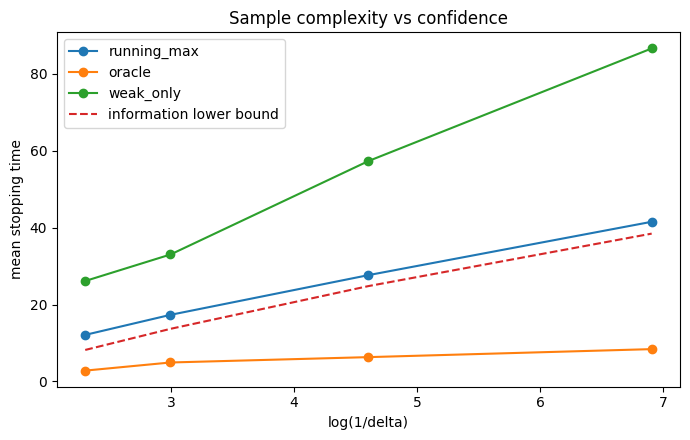

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
for pol in ['running_max','oracle','weak_only']:
    q=main[(main.true_h==0)&(main.policy==pol)].sort_values('delta',ascending=False)
    ax.plot(np.log(1/q.delta),q.mean_tau,marker='o',label=pol)
q=main[(main.true_h==0)&(main.policy=='running_max')].sort_values('delta',ascending=False)
ax.plot(np.log(1/q.delta),q.LB_H0,linestyle='--',label='information lower bound')
ax.set_xlabel('log(1/delta)'); ax.set_ylabel('mean stopping time'); ax.legend(); ax.set_title('Sample complexity vs confidence')
fig.tight_layout(); fig.savefig(ROOT/'figures'/'binary_sample_complexity.png',dpi=180)
plt.show()


## 2. First-order optimality diagnostic

,delta,normalized
0,0.100,5.254963
10,0.050,5.779333
20,0.010,6.001950
30,0.001,6.008705


C_gate = 5.5826261639163635 C_oracle = 1.2022458674074696


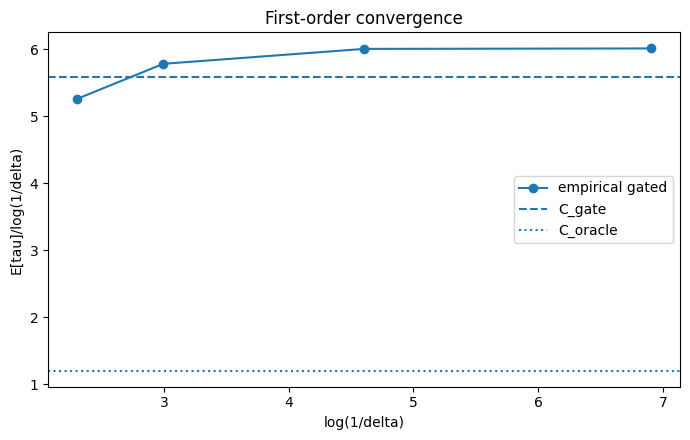

In [6]:
rhos=np.array([0.0,rho,1.0]); d=np.array([weak.d0,strong.d0])
Cgate=theoretical_c_gate(d,rhos); Coracle=1/strong.d0
q=main[(main.true_h==0)&(main.policy=='running_max')].sort_values('delta',ascending=False).copy()
q['normalized']=q.mean_tau/np.log(1/q.delta)
display(q[['delta','normalized']])
print('C_gate =',Cgate,'C_oracle =',Coracle)
fig,ax=plt.subplots(figsize=(7,4.5)); ax.plot(np.log(1/q.delta),q.normalized,marker='o',label='empirical gated')
ax.axhline(Cgate,linestyle='--',label='C_gate'); ax.axhline(Coracle,linestyle=':',label='C_oracle')
ax.set_xlabel('log(1/delta)'); ax.set_ylabel('E[tau]/log(1/delta)'); ax.legend(); ax.set_title('First-order convergence')
fig.tight_layout(); fig.savefig(ROOT/'figures'/'binary_first_order.png',dpi=180); plt.show()


## 3. Price of Certification surface

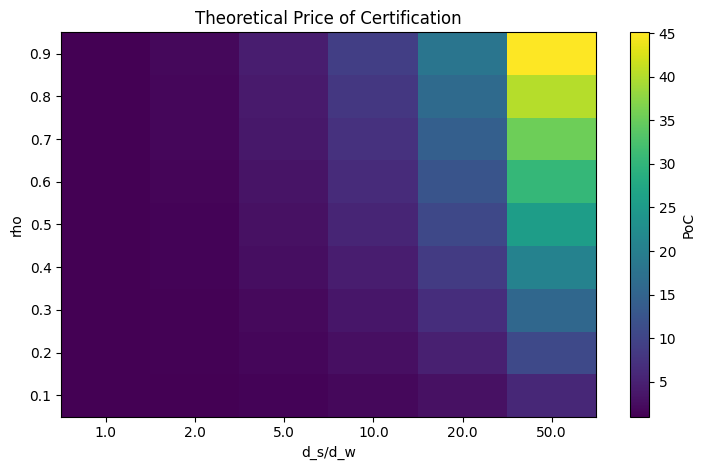

In [7]:
ratios=np.array([1,2,5,10,20,50],dtype=float)
rho_grid=np.arange(.1,1.0,.1)
P=np.array([[1+r*(g-1) for g in ratios] for r in rho_grid])
fig,ax=plt.subplots(figsize=(7.5,4.8)); im=ax.imshow(P,aspect='auto',origin='lower')
ax.set_xticks(range(len(ratios)),ratios); ax.set_yticks(range(len(rho_grid)),[f'{x:.1f}' for x in rho_grid])
ax.set_xlabel('d_s/d_w'); ax.set_ylabel('rho'); ax.set_title('Theoretical Price of Certification')
fig.colorbar(im,ax=ax,label='PoC'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'poc_surface.png',dpi=180); plt.show()


## 4. Empirical Price of Certification across difficulty regimes

,regime,d_w,d_s,d_ratio,theoretical_PoC,empirical_PoC,gated_mean_tau,oracle_mean_tau,gated_error,oracle_error
0,easy,0.831777,2.649995,3.185946,1.874378,1.937500,4.133333,2.133333,0.000000,0.000000
1,moderate,0.082283,0.831777,10.108745,4.643498,4.168342,27.650000,6.633333,0.000000,0.016667
2,hard,0.020136,0.338919,16.831910,7.332764,8.605634,122.200000,14.200000,0.033333,0.000000
3,very_hard,0.005008,0.185712,37.080303,15.432121,11.921053,362.400000,30.400000,0.000000,0.000000
4,large_gap,0.082283,4.503217,54.728487,22.491395,12.868852,26.166667,2.033333,0.033333,0.000000


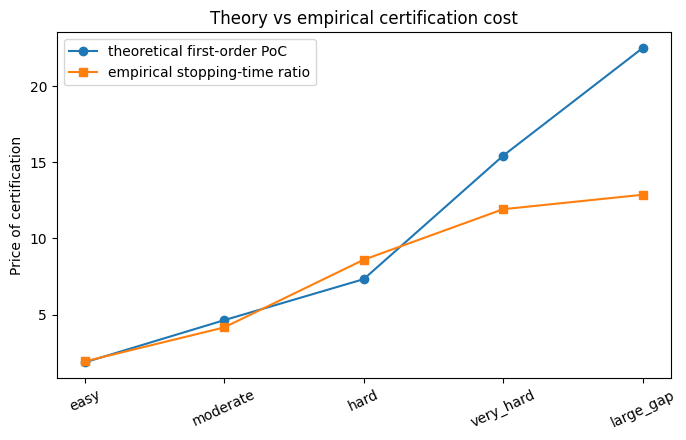

In [8]:
regimes={
    'easy':(.80,.20,.95,.05),
    'moderate':(.70,.50,.80,.20),
    'hard':(.60,.50,.70,.30),
    'very_hard':(.55,.50,.65,.35),
    'large_gap':(.70,.50,.99,.01),
}
delta_reg=.01; alpha_reg=delta_reg**rho
nreg=60 if SMOKE_TEST else (800 if not FULL_RUN else 5000)
reg_rows=[]
for name,(p0w,p1w,p0s,p1s) in regimes.items():
    w=BernoulliAction(p0w,p1w,'weak'); s=BernoulliAction(p0s,p1s,'strong')
    if s.d0 < w.d0:
        raise ValueError(f'{name}: strong action must have at least as much H0 KL as weak action')
    dvec=np.array([w.d0,s.d0]); rvec=np.array([0.,rho,1.])
    poc_th=price_of_certification(dvec,rvec)
    prop=simulate_binary_ladder([w,s],[alpha_reg],delta_reg,0,n_trials=nreg,seed=1200+len(reg_rows),policy='running_max')
    ora=simulate_binary_ladder([w,s],[alpha_reg],delta_reg,0,n_trials=nreg,seed=2200+len(reg_rows),policy='oracle')
    reg_rows.append({'regime':name,'d_w':w.d0,'d_s':s.d0,'d_ratio':s.d0/w.d0,
                     'theoretical_PoC':poc_th,'empirical_PoC':prop.tau.mean()/ora.tau.mean(),
                     'gated_mean_tau':prop.tau.mean(),'oracle_mean_tau':ora.tau.mean(),
                     'gated_error':prop.error.mean(),'oracle_error':ora.error.mean()})
regimes_df=pd.DataFrame(reg_rows); display(regimes_df)
regimes_df.to_csv(ROOT/'results'/'difficulty_regimes_poc.csv',index=False)
fig,ax=plt.subplots(figsize=(7,4.5)); x=np.arange(len(regimes_df)); ax.plot(x,regimes_df.theoretical_PoC,marker='o',label='theoretical first-order PoC'); ax.plot(x,regimes_df.empirical_PoC,marker='s',label='empirical stopping-time ratio'); ax.set_xticks(x,regimes_df.regime,rotation=25); ax.set_ylabel('Price of certification'); ax.legend(); ax.set_title('Theory vs empirical certification cost'); fig.tight_layout(); fig.savefig(ROOT/'figures'/'empirical_poc_regimes.png',dpi=180); plt.show()


## 5. Anytime false-unlock calibration and terminal error

In [9]:
alphas=[.1,.05,.01,.005,.001] if FULL_RUN else [.1,.05,.01]
cal=[]
for alpha in alphas:
    # choose delta below alpha so B < A
    delta=min(alpha/10,1e-3)
    n=500 if SMOKE_TEST else (5000 if not FULL_RUN else (50000 if alpha>=.01 else 100000))
    d1=simulate_binary_ladder(actions,[alpha],delta,1,n_trials=n,seed=33+int(alpha*1e6),policy='running_max')
    s1=summarize_binary_runs(d1)
    d0=simulate_binary_ladder(actions,[alpha],delta,0,n_trials=n,seed=77+int(alpha*1e6),policy='running_max')
    s0=summarize_binary_runs(d0)
    cal.append({'alpha_target':alpha,'delta':delta,'n':n,'false_unlock':s1['false_unlock_rate'],
                'fu_lo':s1['false_unlock_ci_lo'],'fu_hi':s1['false_unlock_ci_hi'],
                'err_H0':s0['error_rate'],'err_H1':s1['error_rate']})
cal=pd.DataFrame(cal); cal.to_csv(ROOT/'results'/'false_unlock_calibration.csv',index=False); display(cal)


,alpha_target,delta,n,false_unlock,fu_lo,fu_hi,err_H0,err_H1
0,0.10,0.001,500,0.072,0.052458,0.098068,0.002,0.002
1,0.05,0.001,500,0.040,0.026041,0.060974,0.000,0.002
2,0.01,0.001,500,0.014,0.006798,0.028613,0.002,0.000


## 6. Finite-confidence decomposition and empirical overshoot

In [10]:
fin=[]
for delta in deltas:
    alpha=delta**rho; beta=delta
    theory=finite_confidence_two_level(weak,strong,delta,alpha,beta)
    df=simulate_binary_ladder(actions,[alpha],delta,0,n_trials=n_trials,seed=909+int(delta*1e6),policy='running_max')
    ovs=df['overshoot1'].dropna()
    fin.append({'delta':delta,'alpha':alpha,'emp_mean_tau':df.tau.mean(),'mean_overshoot':ovs.mean(),
                'q95_overshoot':ovs.quantile(.95) if len(ovs) else np.nan,**theory})
fin=pd.DataFrame(fin); fin.to_csv(ROOT/'results'/'finite_confidence.csv',index=False); display(fin)


,delta,alpha,emp_mean_tau,mean_overshoot,q95_overshoot,Kc,Kf,L_delta,U_thr,U_bd,boundary_factor,overshoot_factor,total_factor
0,0.100,0.398107,11.190000,0.129332,0.250502,0.554615,1.757780,8.186848,12.854472,20.729303,1.570137,1.612614,2.532025
1,0.050,0.301709,19.100000,0.178731,0.309715,0.957819,2.649995,13.674974,16.724053,24.598884,1.222968,1.470869,1.798825
2,0.010,0.158489,26.923333,0.169458,0.326650,1.769371,4.503217,24.790274,25.708944,33.583774,1.037058,1.306307,1.354716
3,0.001,0.063096,41.283333,0.146888,0.280606,2.752497,6.892941,38.429468,38.563415,46.438246,1.003486,1.204205,1.208402


### Interpretation guardrail
The Bernoulli experiments above are **theorem validation** because the action-conditioned laws are known, observations are conditionally independent, and log-likelihood increments are bounded. The empirical curves should be discussed as finite-sample checks of the proved predictions, not as replacements for the proofs.